In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
# !pip install itables
from itables import init_notebook_mode
from itables import show

# Direction

- Please submit your **Python script for Homework 4** to the Brightspace with the name below:

  - `danl-210-hw4-LASTNAME-FIRSTNAME.py`\
  ( e.g., `danl-210-hw4-choe-byeonghak.py` )
  
- For readability, please create a separate cell for each question in your Python script.

- The due is April 30, 2024, 11:59 P.M.

- Please send an email to Byeong-Hak (`bchoe@geneseo.edu`) if you have any questions or clarifications.

<br><br><br>

# Part 1 - Magnificent Seven



<br>

<p align="center">
  <img src="https://bcdanl.github.io/lec_figs/stocks.png" width="600px">
</p>

<br>

Consider the `stock` DataFrame for Part 1.

In [4]:
path = 'https://bcdanl.github.io/data/stock_2019_2024.csv'
stock = pd.read_csv(path)

show(stock)

## Question 1

- Provide both `seaborn` code and a comment to describe how the distribution of the standardized daily `Close` price by `company`.
  - The formula for the standardized daily `Close` price is as follows:
  
$$
z_{t} = \frac{\text{Close}_{t} - \text{mean}(\text{Close}_{t})}{\text{std}(\text{Close}_{t})},
$$
where

- $\text{Close}_{t}$ is a company's `Close` price on date `t`;
- $\text{mean}(\text{Close}_{t})$ is the mean value of `Close` for a company;
- $\text{std}(\text{Close}_{t})$ is the standard deviation of `Close` for a company.


*Answer*:

In [5]:
stock_company = stock.groupby('company')

q1 = (
    stock
    .assign(
        Close_z = ( stock['Close'] - stock_company['Close'].transform('mean') )
                  / stock_company['Close'].transform('std'),
        Close_z_all =
         (stock['Close'] - stock['Close'].mean())
          / stock['Close'].std()  # for comparison
    )
    [['company', 'Date', 'Close', 'Close_z', 'Close_z_all']]
)

show(q1)

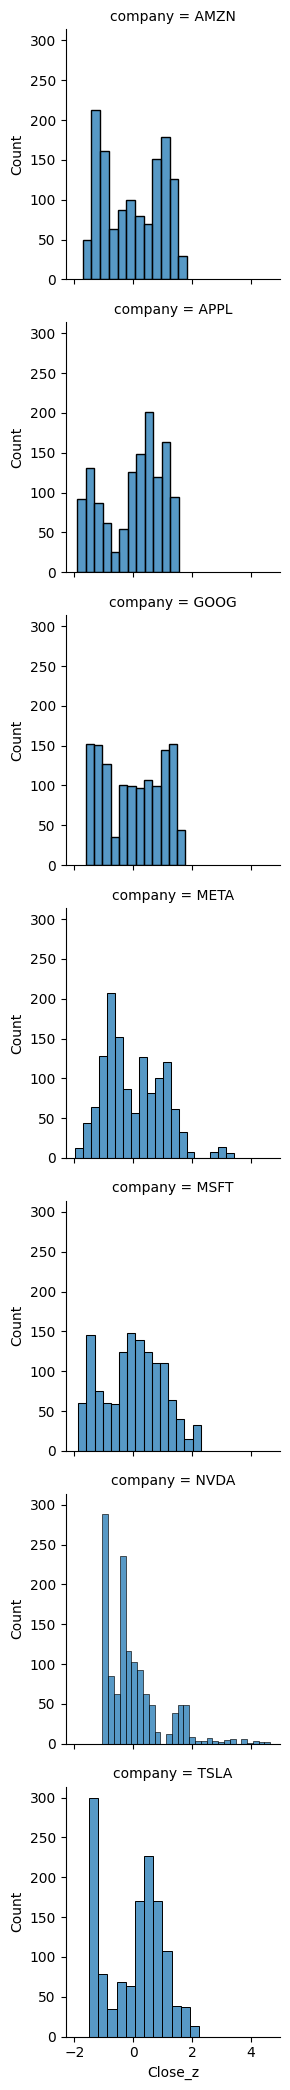

In [7]:
(
 sns.FacetGrid(
       data = q1,
       row= 'company')
 .map(sns.histplot, 'Close_z')
 )

- Comments should not be general but specific.
  - Which values are common? Which values are rare?
  - How is the shape of distribution?
  - How do such things vary by companies?

<br>

## Question 2

- Provide both `seaborn` code and a comment to describe how the daily trend of the `Close` price relative to its value on the first date varies by `company`.


*Answer*:

In [8]:
q2 = (
    stock
    .assign(
        open_rel = stock['Open'] / stock_company['Open'].transform('first'),
        high_rel = stock['High'] / stock_company['High'].transform('first'),
        low_rel = stock['Low'] / stock_company['Low'].transform('first'),
        close_rel = stock['Close'] / stock_company['Close'].transform('first'),
        adj_close_rel = stock['Adj Close'] / stock_company['Adj Close'].transform('first'),
        volume_rel = stock['Volume'] / stock_company['Volume'].transform('first'),
    )[['Date', 'company', 'open_rel', 'high_rel', 'low_rel',
       'close_rel', 'adj_close_rel', 'volume_rel']]
)

show(q2)

<Axes: xlabel='Date', ylabel='close_rel'>

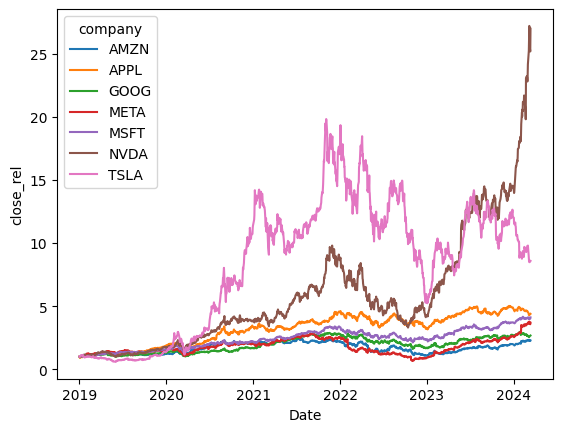

In [11]:
q2['Date'] = pd.to_datetime(q2['Date'])
sns.lineplot(data = q2,
             x =  'Date',
             y =  'close_rel',
             hue = 'company')

- Comments should not be general but specific.
  - How is the trend for each company?

<br><br><br>




# Part 2 - Search Engine Marketing


<br>

<p align="center">
  <img src="https://bcdanl.github.io/lec_figs/ebay-google-mkt.png" width="800px">
</p>

<br>


Load DataFrame for Part 2:

In [14]:
paidsearch = pd.read_csv('https://bcdanl.github.io/data/paidsearch.csv')
show(paidsearch)


##  Variable Description

- `dma`: an identification number of a designated market (DM) area `i` (e.g., Boston, Los Angeles)
- `treatment_period`: 0 if date is before May 22, 2012 and 1 after.
- `search_stays_on`: 1 if the paid-search goes off in dma `i`, 0 otherwise.
- `revenue`: eBay's sales revenue for dma `i` and date `t`

<br>

## Question 3

Use a pivot method to calculate the log difference between mean revenues in each group of `search_stays_on`. (This is the log of the average revenue in group of `search_stays_on` == 1 minus the log of the average revenue in group of `search_stays_on` == 0.)

- For example, consider the following two observations:

In [ ]:
# date        the daily mean vale of `revenue`   search_stays_on
# 1-Apr-12    93650.68                           0
# 1-Apr-12    120277.57                          1

- The log difference of daily mean revenues between the two group of `search_stays_on` for date 1-Apr-12 is log(120277.57) - log(93650.68).


*Answer*:

In [15]:
paidsearch_agg = (
    paidsearch
    .groupby(['date', 'search_stays_on'])
    .agg(revenue_mean = ('revenue', 'mean'))
    .reset_index()
)

show(paidsearch_agg)

In [24]:
q4 = (
    paidsearch_agg
    .pivot(
        index = 'date',
        columns = 'search_stays_on',
        values = 'revenue_mean'
    )
    .rename(columns = {0:'revenue_search_on',
                       1:'revenue_search_off'})
    .assign(
        log_revenue_diff =
            lambda df: np.log(df['revenue_search_on']) - np.log(df['revenue_search_off'])
    )
    .reset_index()
)

show(q4)

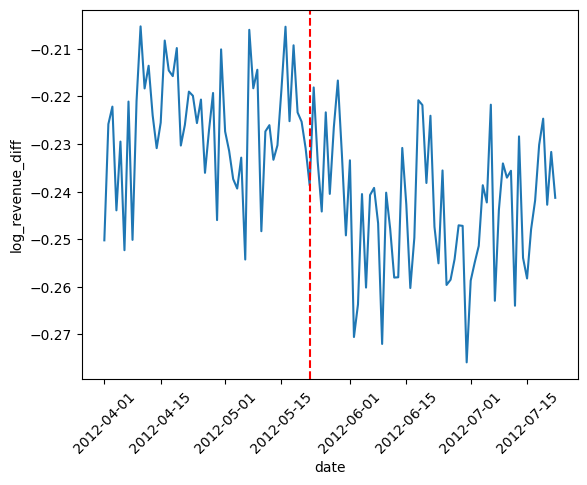

In [27]:
import matplotlib.pyplot as plt

q4['date'] = pd.to_datetime(q4['date'] )

sns.lineplot(
    data = q4,
    x = 'date',
    y = 'log_revenue_diff'
)

plt.axvline(pd.Timestamp('2012-05-22'), color='r', linestyle='--', label='May 22, 2012')
plt.xticks(rotation=45)

plt.show()

<br><br>



# Part 3 - NFL

<br>

<p align="center">
  <img src="https://bcdanl.github.io/lec_figs/nfl.png" width="300px">
</p>

<br>

- The following is the DataFrame for Part 3.

In [18]:
NFL2023_stuffs = pd.read_csv('https://bcdanl.github.io/data/NFL2023_stuffs.csv')
show(NFL2023_stuffs)

- `NFL2023_stuffs` is the DataFrame that contains information about NFL games in year 2022, in which the unit of observation is a single play for each drive in a NFL game.


## Variable description

- `play_id`: Numeric play identifier that when used with `game_id` and `drive` provides the unique identifier for a single play
- `game_id`: Ten digit identifier for NFL game.
- `drive`: Numeric drive number in the game.
- `week`: Season week.
- `posteam`: String abbreviation for the team with possession.
- `qtr`: Quarter of the game (5 is overtime).
- `half_seconds_remaining`: Numeric seconds remaining in the half.
- `down`: The down for the given play.
  - Basically you get four attempts (aka downs) to move the ball 10 yards (by either running with it or passing it).
  - If you make 10 yards then you get another set of four downs.
- `pass`: Binary indicator if the play was a pass play.
- `wp`: Estimated winning probability for the `posteam` given the current situation at the start of the given play.

<br>

## Question 4
- Consider the following DataFrame, `NFL2023_epa`:

In [19]:
NFL2023_epa = pd.read_csv('https://bcdanl.github.io/data/NFL2023_epa.csv')
show(NFL2023_epa)

### Variable Description for `NFL2023_epa`

  - `play_id`: Numeric play identifier that when used with `game_id` and `drive` provides the unique identifier for a single play
  - `game_id`: Ten digit identifier for NFL game.
  - `drive`: Numeric drive number in the game.
  - `posteam`: String abbreviation for the team with possession.
  - `passer`: Name of the player who passed a ball to a receiver by initially taking a three-step drop and backpedaling into the pocket to make a pass. (Mostly, they are quarterbacks)
  - `receiver`: Name of the receiver.
  - `epa`: Expected points added (EPA) by the `posteam` for the given play.

<br>

- Create the DataFrame, `NFL2023_stuffs_EPA`, that includes
  1. All the variables in the DataFrame, `NFL2023_stuffs`;
  2. The variables, `passer`, `receiver`, and `epa`, from the DataFrame, `NFL2023_epa`.
by joining the two DataFrames.

- In the resulting DataFrame, `NFL2023_stuffs_EPA`, please include all the observations in the `NFL2023_stuffs`, except for the observations with the missing values in the `passer` variable.

- Please explain how you identify the set of key variables when joining the two DataFrames.

*Answer*:

In [20]:
NFL2023_stuffs_EPA = (
    NFL2023_stuffs
    .merge(NFL2023_epa, on = ['play_id', 'game_id', 'drive', 'posteam'], how = 'left')
    .dropna(subset = ['passer'])
)

show(NFL2023_stuffs_EPA)

<br><br><br>



# Part 4 - Web Scrapping with `selenium`

- Go to the following IMDB webpage for
  - [Top Family Movies and TV Shows (sorted by popularity)](https://www.imdb.com/search/title/?genres=family)


## Question 5

- Provide your Python Selenium codes to scrape the table for Top 200 Family Movies and TV Shows.
  - You should create the following variables in the DataFrame:
    - `ranking`	(e.g., 1, 2, 3)
    - `title`	(e.g., Wish, Harry Potter and the Sorcerer's Stone)
    - `year`	(e.g., 2023, 2024-)
    - `runtime`	(e.g., 1h 56m, 1h 40m)
    - `rating` (e.g., PG, TV-G, G)
    - `imdb_score` (e.g., 7.6, 6.5)
    - `votes` (e.g., 1.4k, 70k)
    - `metascore`	(e.g., 56, 74)
    - `plot` (e.g., A young girl named Asha wishes on a star and gets a more direct answer than she bargained for when a trouble-making star comes down from the sky to join her.)


- Suppose `ranking` and `title` are in one column, `ranking_title`. For example,
  - "1.	Transformers One"
  - "2. The Spiderwick Chronicles"
- Then, we can use the code below:

In [ ]:
# Split the 'ranking_title' column into two new variables, 'ranking' and 'title'
# by the first occurrence of a period (dot).

# n=1 ensures the split to be limited to the first dot.
# expand=True tells pandas to return the results in a DataFrame
  # If expand were False, the result would be a Series of lists.

df[['ranking', 'title']] = df['ranking_title'].str.split('.', n=1, expand=True)
df = df.drop(columns=['ranking_title'])

- Save the DataFrame in the CSV file.


*Answer*:

In [ ]:
#| eval: false

#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Created on Mon May 6 20:10:43 2024

@author: byeong-hakchoe
"""

# %%
# loading libraries
import pandas as pd
import numpy as np
import os
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.common.by import By
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
import time
# %%
# working directory

# wd_path = '/Users/byeong-hakchoe/Downloads'
wd_path = '/Users/bchoe/My Drive/suny-geneseo/spring2024/lecture-codes'
os.chdir(wd_path)
os.getcwd()

# %%
# chrome browser with options
# options = Options()
# options.add_argument("window-size=1400,1200")
# driver_path = "/Users/byeong-hakchoe/Downloads/chromedriver-mac-x64/chromedriver"
# s = Service(driver_path)
# driver = webdriver.Chrome(options = options, service=s)
driver = webdriver.Chrome()
# driver.implicitly_wait(5)

url = 'https://www.imdb.com/search/title/?genres=family'
driver.get(url)

# %%

xpath = '/html/body/div[2]/main/div[2]/div[3]/section/section/div/section/section/div[2]/div/section/div[2]/div[2]/div[2]/div/span/button/span/span'

for i in range(0,7):
    try:    
        btn = driver.find_element(By.XPATH, xpath)
        btn.click()
        time.sleep(5)
    except:
        pass

xpath_lst = '/html/body/div[2]/main/div[2]/div[3]/section/section/div/section/section/div[2]/div/section/div[2]/div[2]/ul'
lst = driver.find_element(By.XPATH, xpath_lst)
items = lst.find_elements(By.TAG_NAME, 'li')

df = pd.DataFrame()
for i in range(0, len(items)):
    ranking_title = items[i].find_element(By.CLASS_NAME, 'ipc-title__text').text

    try:
        xpath_meta = '/html/body/div[2]/main/div[2]/div[3]/section/section/div/section/section/div[2]/div/section/div[2]/div[2]/ul/li['+str(i+1)+']/div/div/div/div[1]/div[2]/div[2]'
        year_runtime_rating = driver.find_element(By.XPATH, xpath_meta)
        year_runtime_rating = year_runtime_rating.find_elements(By.TAG_NAME, 'span')

        if len(year_runtime_rating) == 3:
            year =  year_runtime_rating[0].text
            runtime = year_runtime_rating[1].text
            rating = year_runtime_rating[2].text
        elif len(year_runtime_rating) == 1:
            year =  year_runtime_rating[0].text
            runtime = ''
            rating = ''
        else:
            year =  year_runtime_rating[0].text

            if ('h' in year_runtime_rating[1].text) & ('m' in year_runtime_rating[1].text):
                runtime = year_runtime_rating[1].text
                rating = ''
            else:
                runtime = ''
                rating = year_runtime_rating[1].text
    except:
        year = ''
        runtime = ''
        rating = ''

    try:
        xpath_imdb_score = '/html/body/div[2]/main/div[2]/div[3]/section/section/div/section/section/div[2]/div/section/div[2]/div[2]/ul/li['+str(i+1)+']/div/div/div/div[1]/div[2]/span/div/span'
        imdb_score = driver.find_element(By.XPATH, xpath_imdb_score).get_attribute('aria-label')
    except:
        imdb_score = ''

    try:
        vote = items[i].find_element(By.CLASS_NAME, 'ipc-rating-star--voteCount').text
    except:
        vote = ''

    try:
        xpath_metascore = '/html/body/div[2]/main/div[2]/div[3]/section/section/div/section/section/div[2]/div/section/div[2]/div[2]/ul/li['+str(i+1)+']/div/div/div/div[1]/div[2]/span/span/span[1]'
        metascore = driver.find_element(By.XPATH, xpath_metascore).text
    except:
        metascore = ''

    plot = items[i].find_element(By.CLASS_NAME, 'ipc-html-content-inner-div').text

    ranking_title = pd.DataFrame([ranking_title])
    year = pd.DataFrame([year])
    runtime = pd.DataFrame([runtime])
    rating = pd.DataFrame([rating])
    imdb_score = pd.DataFrame([imdb_score])
    vote = pd.DataFrame([vote])
    metascore = pd.DataFrame([metascore])
    plot = pd.DataFrame([plot])

    obs = pd.concat([ranking_title, year, runtime, rating,
                     imdb_score, vote, metascore, plot], axis = 1)
    df = pd.concat([df, obs])


df.columns = ['ranking_title', 'year', 'runtime', 'rating',
                 'imdb_score', 'vote', 'metascore', 'plot']
df[['ranking', 'title']] = df['ranking_title'].str.split('.', n=1, expand=True)
df = df.drop(columns=['ranking_title'])
df['imdb_score'] = df['imdb_score'].str.replace('This title is currently not ratable', '')
df['imdb_score'] = df['imdb_score'].str.replace('IMDb rating: ', '')
df['vote'] = df['vote'].str.replace(' (', '')
df['vote'] = df['vote'].str.replace(')', '')


df.to_csv('imdb_family_2024_0506.csv')

# %%
# =============================================================================
#
# =============================================================================

# Blank


<br><br>